# Feature extraction from thermal fields

## Config

In [1]:
import pandas as pd

resolution = 600 # in seconds --> 10 minutes
hive_nb = 1
ihl = "upper"
start_ts=pd.Timestamp('2024-09-04 01:00:00Z')
end_ts=pd.Timestamp('2024-10-29 23:00:00Z')

## Imports

In [2]:
import sys
sys.path.append('RHCThermalPlots/')
from RHCThermalPlots.thermalframe import ThermalFrame
from RHCThermalPlots.InfluxDBInterface.libdb import download_tmp_DB
import matplotlib.pyplot as plt
import numpy as np

## Main code

In [3]:
filters = {
        "hive_num" : hive_nb,
        "inhive_loc" : ihl,
    }
tmp_df = download_tmp_DB('ObsHiveABC', start_ts, end_ts, resolution = resolution, filters = filters, aggr = "last")

vmin: 18.828125, vmax: 36.5546875


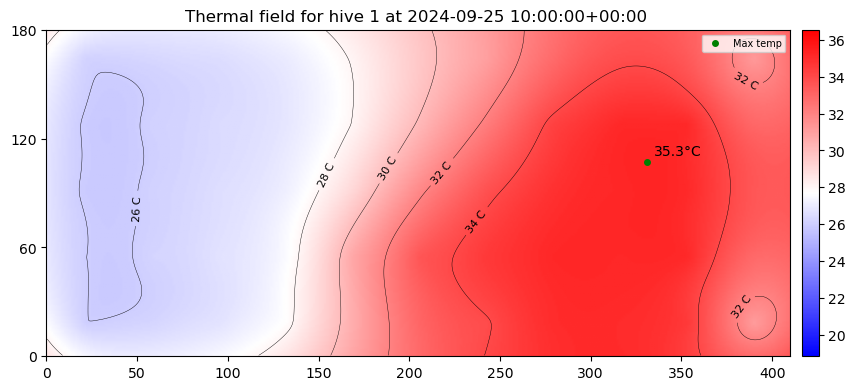

In [4]:
import importlib
import RHCThermalPlots.thermalframe as thermalframe
importlib.reload(thermalframe)
from RHCThermalPlots.thermalframe import ThermalFrame

vmin = tmp_df.iloc[:, :].min().min()
vmax = tmp_df.iloc[:, :].max().max()
print(f"vmin: {vmin}, vmax: {vmax}")
index = 3000

tf = ThermalFrame(tmp_df.iloc[index].to_numpy(), hive_nb, tmp_df.index[index])

contours = np.arange(12, vmax, 2)

fig, ax = plt.subplots(figsize=(12, 6))
tf.plot_thermal_field(ax=ax, annotate_contours = True, v_min=vmin, v_max=vmax, contours=contours, show_max_temp = True, verbose = False)
plt.show()